
Bluetooth RF Fingerprinting Project
According to Research Paper


In [2]:
import os

import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

from pathlib import Path

import warnings
warnings.filterwarnings("ignore")

In [3]:
import os

# Change this path according to your dataset location
dataset_path = r"C:\Users\user\OneDrive\Desktop\TASL_PROJECT1\Dataset 250 Msps"

print(dataset_path)

C:\Users\user\OneDrive\Desktop\TASL_PROJECT1\Dataset 250 Msps


In [4]:
import os

# Root dataset folder
dataset_path = r"C:\Users\user\OneDrive\Desktop\TASL_PROJECT1\Dataset 250 Msps"

# Show all main folders
folders = os.listdir(dataset_path)

print(folders)

['Iphone', 'LG', 'Samsung', 'Sony', 'Xiaomi']


In [5]:
for folder in folders:
    print(folder)

Iphone
LG
Samsung
Sony
Xiaomi


In [6]:
# =====================================================
# STEP 3 : Explore Dataset
# =====================================================

brands = os.listdir(dataset_path)

print("Available Brands:\n")

for brand in brands:
    print(brand)

print("\nTotal Brands :", len(brands))

Available Brands:

Iphone
LG
Samsung
Sony
Xiaomi

Total Brands : 5


In [7]:
print("Phone Models\n")

total_models = 0

for brand in brands:

    brand_path = os.path.join(dataset_path, brand)

    models = os.listdir(brand_path)

    print(f"{brand} : {models}")

    total_models += len(models)

print("\nTotal Phone Models :", total_models)

Phone Models

Iphone : ['4s', '5', '5s', '6', '6S', '7', '7plus']
LG : ['G4', 'V20']
Samsung : ['J7', 'Note2', 'note3', 'S5', 'S7 edge']
Sony : ['XperiaM5']
Xiaomi : ['Mi6']

Total Phone Models : 16


In [8]:
# Count signal files in every phone model

for brand in brands:

    brand_path = os.path.join(dataset_path, brand)

    models = os.listdir(brand_path)

    print(f"\n========== {brand} ==========")

    for model in models:

        model_path = os.path.join(brand_path, model)

        total_files = len(os.listdir(model_path))

        print(f"{model} --> {total_files} signal files")


========== Iphone ==========
4s --> 2 signal files
5 --> 2 signal files
5s --> 2 signal files
6 --> 2 signal files
6S --> 3 signal files
7 --> 2 signal files
7plus --> 2 signal files

========== LG ==========
G4 --> 2 signal files
V20 --> 2 signal files

========== Samsung ==========
J7 --> 2 signal files
Note2 --> 2 signal files
note3 --> 2 signal files
S5 --> 2 signal files
S7 edge --> 2 signal files

========== Sony ==========
XperiaM5 --> 2 signal files

========== Xiaomi ==========
Mi6 --> 2 signal files


In [9]:
# Select one Bluetooth signal file

sample_file = os.path.join(
    dataset_path,
    "Iphone",
    "7plus",
    os.listdir(os.path.join(dataset_path, "Iphone", "7plus"))[0]
)

print(sample_file)

C:\Users\user\OneDrive\Desktop\TASL_PROJECT1\Dataset 250 Msps\Iphone\7plus\355373083202269_akin_yavuz


In [11]:
print(sample_file)

C:\Users\user\OneDrive\Desktop\TASL_PROJECT1\Dataset 250 Msps\Iphone\7plus\355373083202269_akin_yavuz


In [12]:
iphone7plus_path = os.path.join(dataset_path, "Iphone", "7plus")

person_folder = os.listdir(iphone7plus_path)[0]

person_path = os.path.join(iphone7plus_path, person_folder)

txt_file = os.listdir(person_path)[0]

sample_file = os.path.join(person_path, txt_file)

print(sample_file)

C:\Users\user\OneDrive\Desktop\TASL_PROJECT1\Dataset 250 Msps\Iphone\7plus\355373083202269_akin_yavuz\355373083202269_akin_yavuz_ro_iphone_7plus_record001.txt


In [13]:
signal = np.loadtxt(sample_file)

print(signal[:10])


[0.0022 0.0022 0.002  0.0022 0.0022 0.0024 0.0022 0.0022 0.0016 0.0018]


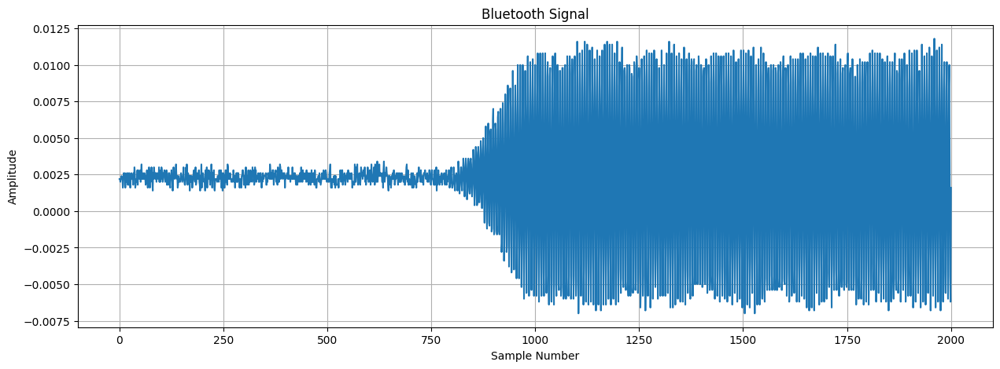

In [14]:
# Plot Bluetooth Signal

plt.figure(figsize=(15,5))

plt.plot(signal)

plt.title("Bluetooth Signal")

plt.xlabel("Sample Number")

plt.ylabel("Amplitude")

plt.grid(True)

plt.show()

In [15]:
import os
import numpy as np

user1_path = os.path.join(
    dataset_path,
    "Iphone",
    "7plus",
    "355373083202269_akin_yavuz"
)

user1_signals = []

for file in sorted(os.listdir(user1_path)):

    if file.endswith(".txt"):

        signal = np.loadtxt(os.path.join(user1_path,file))

        user1_signals.append(signal)

print("Total Signals :",len(user1_signals))

Total Signals : 150


In [16]:
user2_path = os.path.join(
    dataset_path,
    "Iphone",
    "7plus",
    "359179071432156_melisa_topcu"
)

user2_signals=[]

for file in sorted(os.listdir(user2_path)):

    if file.endswith(".txt"):

        signal=np.loadtxt(os.path.join(user2_path,file))

        user2_signals.append(signal)

print("Total Signals :",len(user2_signals))

Total Signals : 150


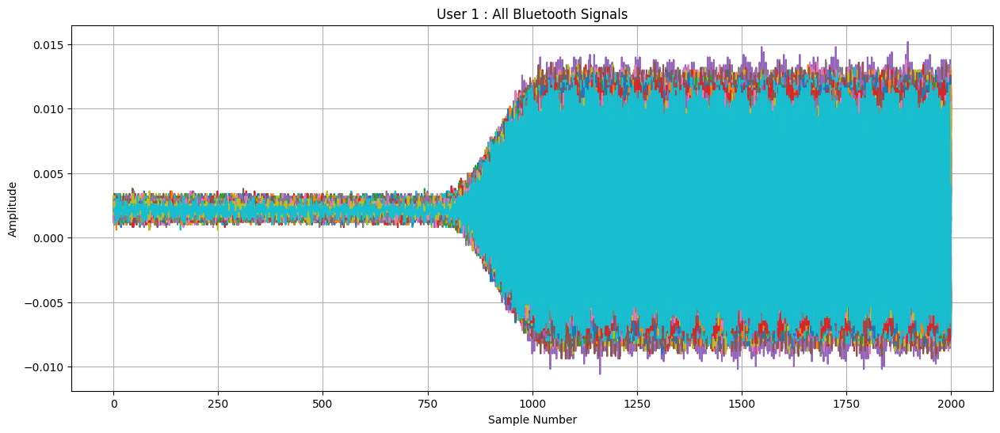

In [17]:
plt.figure(figsize=(15,6))

for signal in user1_signals:

    plt.plot(signal)

plt.title("User 1 : All Bluetooth Signals")

plt.xlabel("Sample Number")

plt.ylabel("Amplitude")

plt.grid(True)

plt.show()

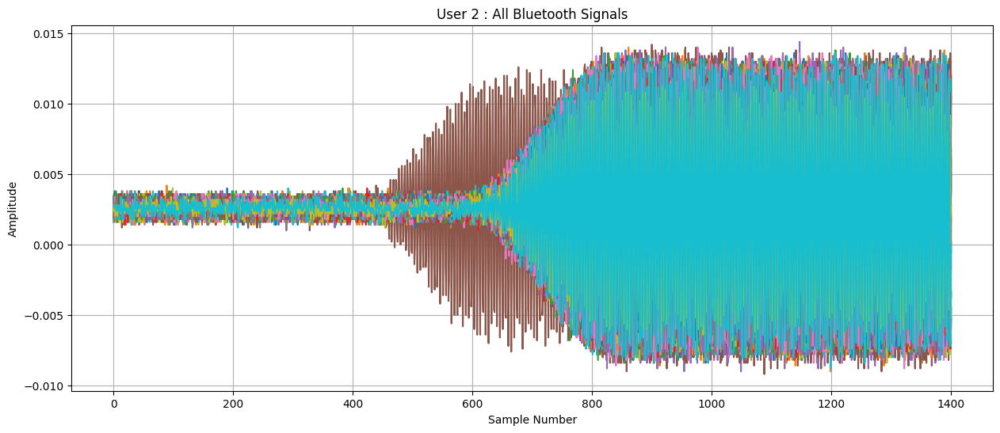

In [18]:
plt.figure(figsize=(15,6))

for signal in user2_signals:

    plt.plot(signal)

plt.title("User 2 : All Bluetooth Signals")

plt.xlabel("Sample Number")

plt.ylabel("Amplitude")

plt.grid(True)

plt.show()

In [19]:
user1_average=np.mean(user1_signals,axis=0)

user2_average=np.mean(user2_signals,axis=0)

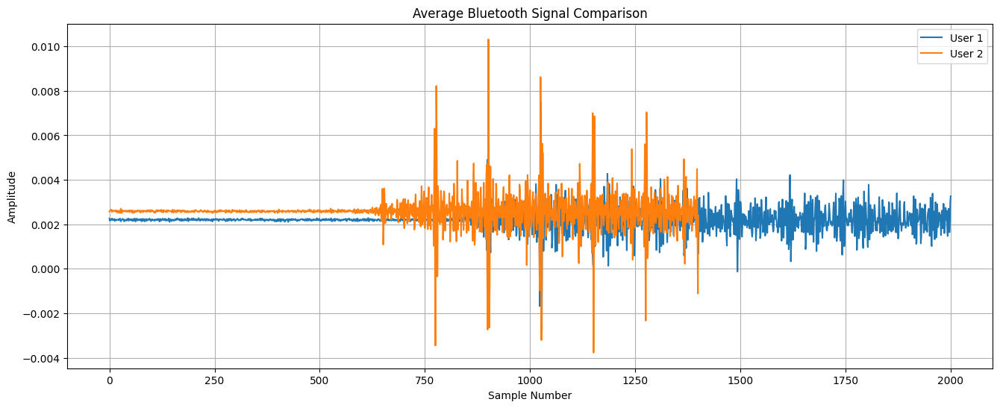

In [20]:
plt.figure(figsize=(16,6))

plt.plot(user1_average,label="User 1")

plt.plot(user2_average,label="User 2")

plt.title("Average Bluetooth Signal Comparison")

plt.xlabel("Sample Number")

plt.ylabel("Amplitude")

plt.legend()

plt.grid(True)

plt.show()

In [21]:
# ==========================================================
# STEP 7 : Load Complete Dataset
# ==========================================================

complete_dataset = []

In [22]:
brands = sorted(os.listdir(dataset_path))

for brand in brands:

    brand_path = os.path.join(dataset_path, brand)

    print(brand)

Iphone
LG
Samsung
Sony
Xiaomi


In [23]:
brands = sorted(os.listdir(dataset_path))

for brand in brands:

    brand_path = os.path.join(dataset_path, brand)

    models = sorted(os.listdir(brand_path))

    for model in models:

        print(brand,"->",model)

Iphone -> 4s
Iphone -> 5
Iphone -> 5s
Iphone -> 6
Iphone -> 6S
Iphone -> 7
Iphone -> 7plus
LG -> G4
LG -> V20
Samsung -> J7
Samsung -> Note2
Samsung -> S5
Samsung -> S7 edge
Samsung -> note3
Sony -> XperiaM5
Xiaomi -> Mi6


In [24]:
brands = sorted(os.listdir(dataset_path))

for brand in brands:

    brand_path = os.path.join(dataset_path, brand)

    models = sorted(os.listdir(brand_path))

    for model in models:

        model_path = os.path.join(brand_path, model)

        users = sorted(os.listdir(model_path))

        for user in users:

            print(brand,"->",model,"->",user)
            

Iphone -> 4s -> 013004004984503_oguz_guler
Iphone -> 4s -> 013051002641007_koray_oktem
Iphone -> 5 -> 013409009258565_gamze_uyuk
Iphone -> 5 -> 013737001703349_makbule_guclu
Iphone -> 5s -> 352053069423260_mustafa_gungor
Iphone -> 5s -> 359261061140526_melisa_topcu
Iphone -> 6 -> 354427066558690_mustafa_guclu
Iphone -> 6 -> 355401074766578_berat_serefoglu
Iphone -> 6S -> 353308076325778_tugce_ozkan
Iphone -> 6S -> 355396082974273_melisa_oktem
Iphone -> 6S -> 355694077593599_deniz_yilmaz
Iphone -> 7 -> 356563081643675_cuneyt_buyukkilic
Iphone -> 7 -> 359206078179249_ismet_buyukkilic
Iphone -> 7plus -> 355373083202269_akin_yavuz
Iphone -> 7plus -> 359179071432156_melisa_topcu
LG -> G4 -> 352334072148270_mertcan_yurtseven
LG -> G4 -> 352334073607175_mert_kilic
LG -> V20 -> 3521162080037221_ozan_erbasan
LG -> V20 -> 352162080046735_melis_yilmaz
Samsung -> J7 -> 352952078845142_omerfaruk_altuntas
Samsung -> J7 -> 359947076663425_onder_sahin
Samsung -> Note2 -> 355056057465265_yesim_balci
Sa

In [25]:
brands = sorted(os.listdir(dataset_path))

for brand in brands:

    brand_path = os.path.join(dataset_path, brand)

    models = sorted(os.listdir(brand_path))

    for model in models:

        model_path = os.path.join(brand_path, model)

        users = sorted(os.listdir(model_path))

        for user in users:

            user_path = os.path.join(model_path, user)

            txt_files = sorted(os.listdir(user_path))

            print(brand,model,user,len(txt_files))

Iphone 4s 013004004984503_oguz_guler 151
Iphone 4s 013051002641007_koray_oktem 150
Iphone 5 013409009258565_gamze_uyuk 150
Iphone 5 013737001703349_makbule_guclu 150
Iphone 5s 352053069423260_mustafa_gungor 150
Iphone 5s 359261061140526_melisa_topcu 150
Iphone 6 354427066558690_mustafa_guclu 150
Iphone 6 355401074766578_berat_serefoglu 150
Iphone 6S 353308076325778_tugce_ozkan 150
Iphone 6S 355396082974273_melisa_oktem 150
Iphone 6S 355694077593599_deniz_yilmaz 150
Iphone 7 356563081643675_cuneyt_buyukkilic 150
Iphone 7 359206078179249_ismet_buyukkilic 150
Iphone 7plus 355373083202269_akin_yavuz 150
Iphone 7plus 359179071432156_melisa_topcu 150
LG G4 352334072148270_mertcan_yurtseven 150
LG G4 352334073607175_mert_kilic 150
LG V20 3521162080037221_ozan_erbasan 150
LG V20 352162080046735_melis_yilmaz 150
Samsung J7 352952078845142_omerfaruk_altuntas 150
Samsung J7 359947076663425_onder_sahin 150
Samsung Note2 355056057465265_yesim_balci 150
Samsung Note2 356261053336200_ismet_buyukkilic

In [26]:
# ==========================================================
# STEP 8 : Load Complete Bluetooth Dataset
# ==========================================================

complete_dataset = []

brands = sorted(os.listdir(dataset_path))

for brand in brands:

    brand_path = os.path.join(dataset_path, brand)

    models = sorted(os.listdir(brand_path))

    for model in models:

        model_path = os.path.join(brand_path, model)

        users = sorted(os.listdir(model_path))

        for user in users:

            user_path = os.path.join(model_path, user)

            txt_files = sorted(os.listdir(user_path))

            for txt_file in txt_files:

                if txt_file.endswith(".txt"):

                    file_path = os.path.join(user_path, txt_file)

                    signal = np.loadtxt(file_path)

                    complete_dataset.append({

                        "Brand": brand,

                        "Model": model,

                        "User": user,

                        "File": txt_file,

                        "Signal": signal

                    })

print("Total Bluetooth Signals Loaded :", len(complete_dataset))


Total Bluetooth Signals Loaded : 4951


In [27]:
print(complete_dataset[0])

{'Brand': 'Iphone', 'Model': '4s', 'User': '013004004984503_oguz_guler', 'File': '013004004984503_oguz_guler_ro_iphone_4s_record001 - Copy.txt', 'Signal': array([ 0.0031,  0.0023,  0.0023, ...,  0.0105, -0.0001, -0.0057],
      shape=(2151,))}


In [28]:
print(complete_dataset[100])

{'Brand': 'Iphone', 'Model': '4s', 'User': '013004004984503_oguz_guler', 'File': '013004004984503_oguz_guler_ro_iphone_4s_record100.txt', 'Signal': array([ 0.0023,  0.0025,  0.0025, ..., -0.0009, -0.0045,  0.0073],
      shape=(2151,))}


In [29]:
dataset_info = []

for item in complete_dataset:

    dataset_info.append({

        "Brand": item["Brand"],

        "Model": item["Model"],

        "User": item["User"],

        "File": item["File"],

        "Signal Length": len(item["Signal"])

    })

df = pd.DataFrame(dataset_info)

df.head()

,Brand,Model,User,File,Signal Length
0,Iphone,4s,013004004984503_oguz_guler,013004004984503_oguz_guler_ro_iphone_4s_record...,2151
1,Iphone,4s,013004004984503_oguz_guler,013004004984503_oguz_guler_ro_iphone_4s_record...,2151
2,Iphone,4s,013004004984503_oguz_guler,013004004984503_oguz_guler_ro_iphone_4s_record...,2151
3,Iphone,4s,013004004984503_oguz_guler,013004004984503_oguz_guler_ro_iphone_4s_record...,2151
4,Iphone,4s,013004004984503_oguz_guler,013004004984503_oguz_guler_ro_iphone_4s_record...,2151


In [30]:
df["Brand"].value_counts()

Brand
Iphone     2251
Samsung    1500
LG          600
Sony        300
Xiaomi      300
Name: count, dtype: int64

In [31]:
df["Model"].value_counts()

Model
6S          450
4s          301
5           300
5s          300
6           300
7           300
7plus       300
G4          300
V20         300
J7          300
Note2       300
S5          300
S7 edge     300
note3       300
XperiaM5    300
Mi6         300
Name: count, dtype: int64

In [32]:
df["Signal Length"].describe()

count    4951.000000
mean     2184.599273
std       363.221629
min      1401.000000
25%      2001.000000
50%      2151.000000
75%      2451.000000
max      3001.000000
Name: Signal Length, dtype: float64

In [33]:
print(df["Signal Length"].describe())

count    4951.000000
mean     2184.599273
std       363.221629
min      1401.000000
25%      2001.000000
50%      2151.000000
75%      2451.000000
max      3001.000000
Name: Signal Length, dtype: float64


In [34]:
signal_lengths = df["Signal Length"].value_counts().sort_index()

print(signal_lengths)

Signal Length
1401     441
1901     450
2001    1200
2151     751
2401     309
2451     900
2501     600
2851     151
3001     149
Name: count, dtype: int64


In [35]:
empty_files = df[df["Signal Length"]==0]

print(empty_files)

Empty DataFrame
Columns: [Brand, Model, User, File, Signal Length]
Index: []


In [36]:
print(df.isnull().sum())

Brand            0
Model            0
User             0
File             0
Signal Length    0
dtype: int64


In [37]:
brand_distribution = df["Brand"].value_counts()

print(brand_distribution)

Brand
Iphone     2251
Samsung    1500
LG          600
Sony        300
Xiaomi      300
Name: count, dtype: int64


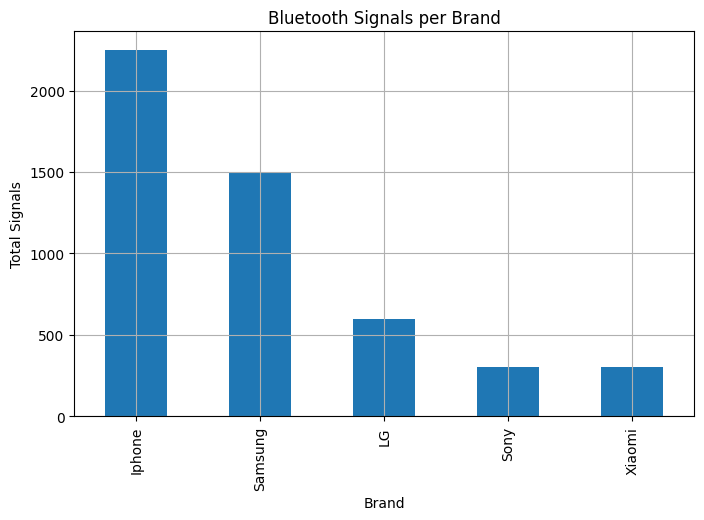

In [38]:
plt.figure(figsize=(8,5))

brand_distribution.plot(kind="bar")

plt.title("Bluetooth Signals per Brand")

plt.xlabel("Brand")

plt.ylabel("Total Signals")

plt.grid(True)

plt.show()

Brand
Iphone     2251
Samsung    1500
LG          600
Sony        300
Xiaomi      300
Name: count, dtype: int64


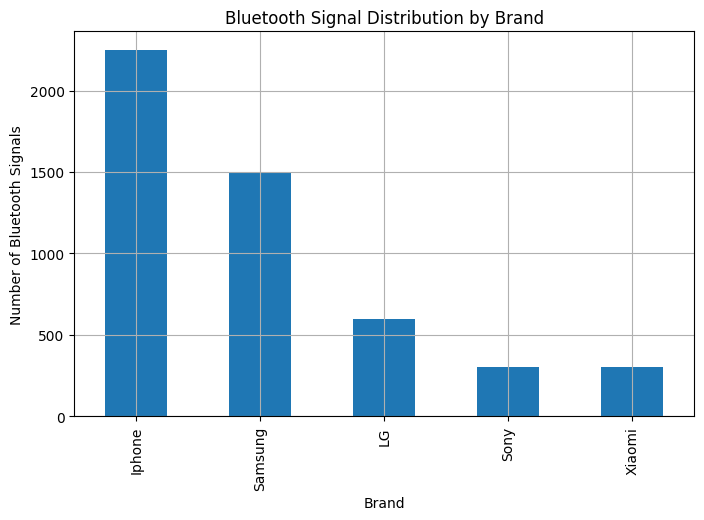

In [39]:
# ===============================================================
# 4.1 Brand Distribution
# ===============================================================

brand_distribution = df["Brand"].value_counts()

print(brand_distribution)

plt.figure(figsize=(8,5))

brand_distribution.plot(kind="bar")

plt.title("Bluetooth Signal Distribution by Brand")

plt.xlabel("Brand")

plt.ylabel("Number of Bluetooth Signals")

plt.grid(True)

plt.show()

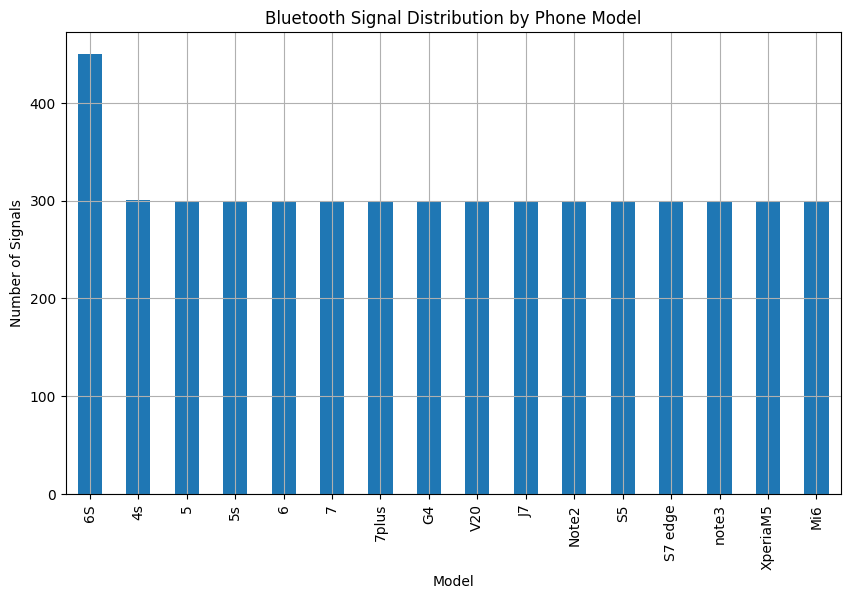

In [40]:
model_distribution = df["Model"].value_counts()

plt.figure(figsize=(10,6))

model_distribution.plot(kind="bar")

plt.title("Bluetooth Signal Distribution by Phone Model")

plt.xlabel("Model")

plt.ylabel("Number of Signals")

plt.grid(True)

plt.show()

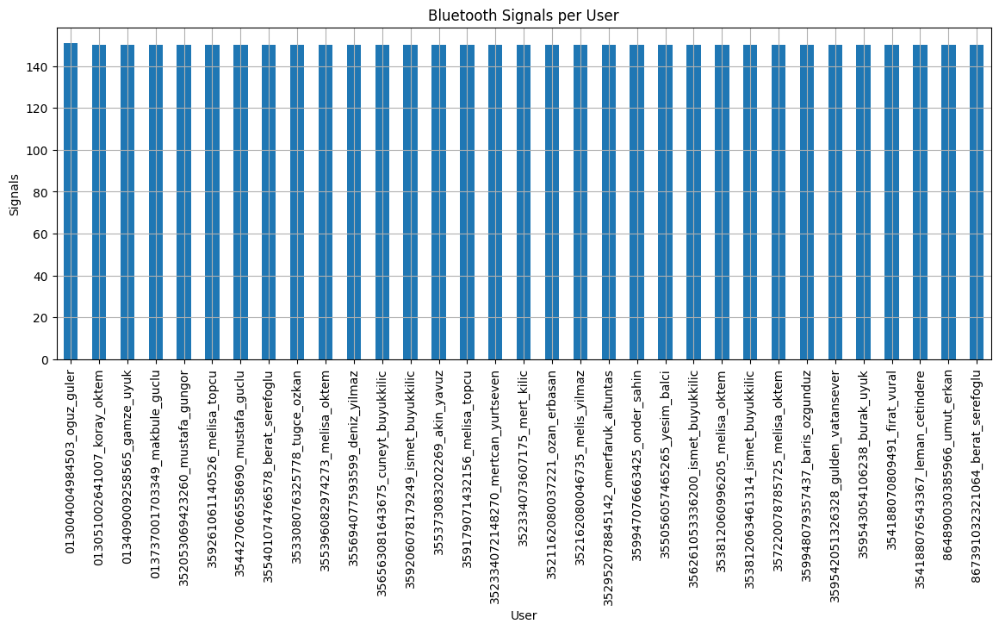

In [41]:
user_distribution = df["User"].value_counts()

plt.figure(figsize=(14,5))

user_distribution.plot(kind="bar")

plt.title("Bluetooth Signals per User")

plt.xlabel("User")

plt.ylabel("Signals")

plt.grid(True)

plt.show()

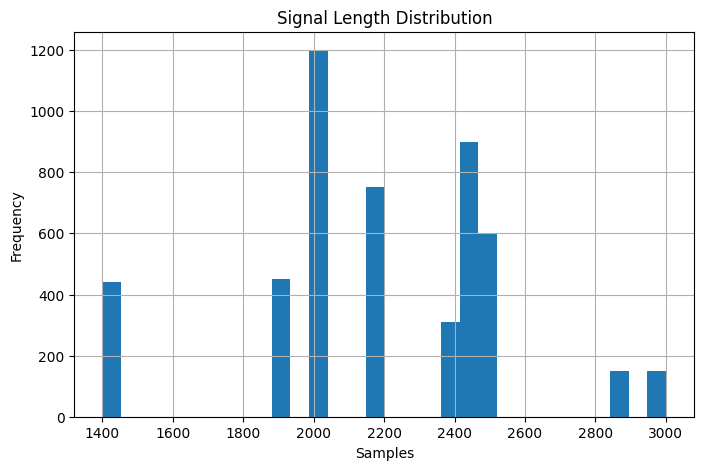

In [42]:
plt.figure(figsize=(8,5))

plt.hist(df["Signal Length"],bins=30)

plt.title("Signal Length Distribution")

plt.xlabel("Samples")

plt.ylabel("Frequency")

plt.grid(True)

plt.show()

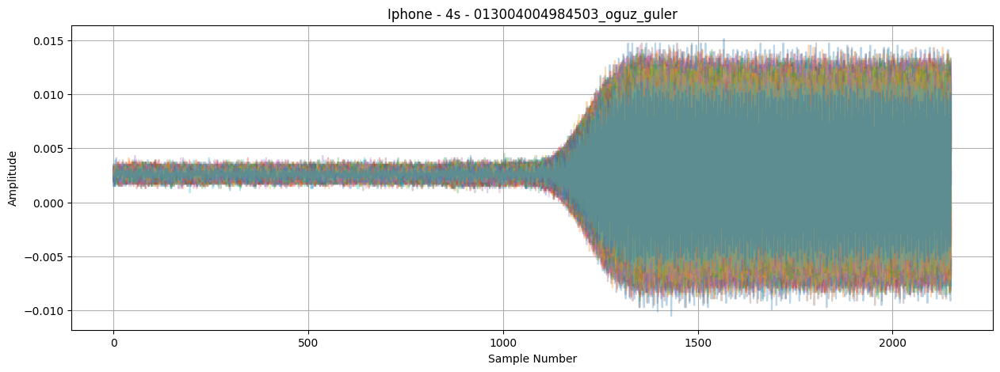

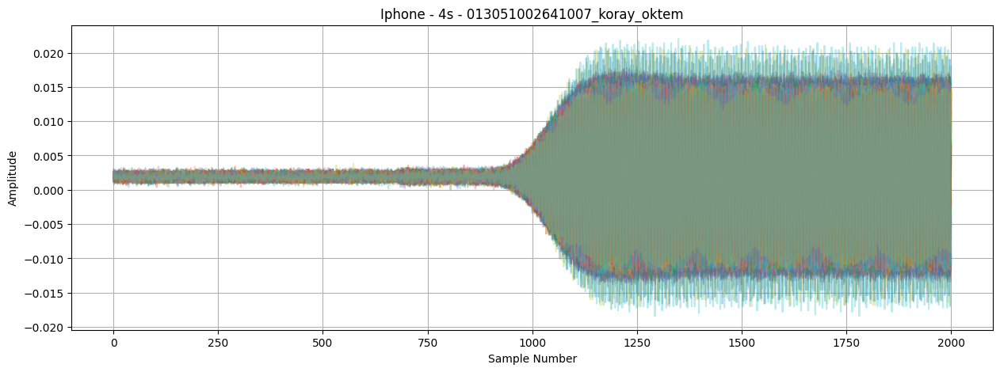

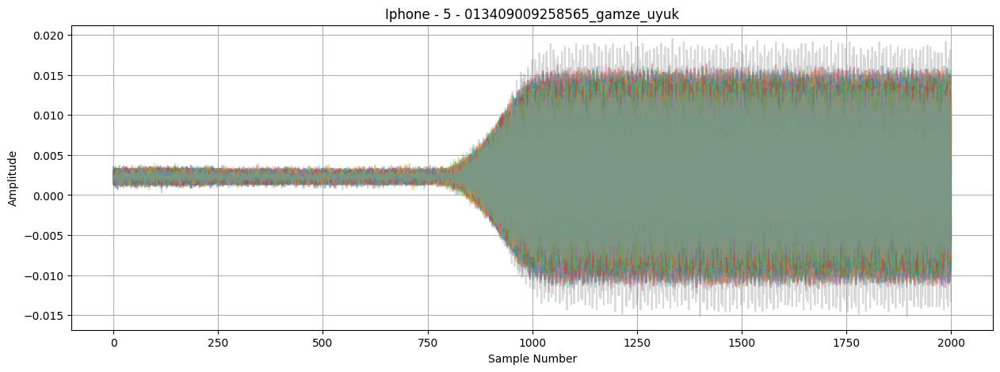

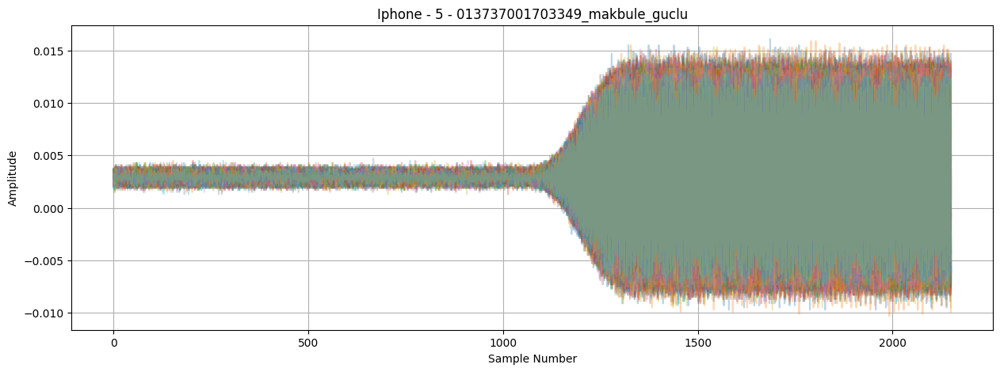

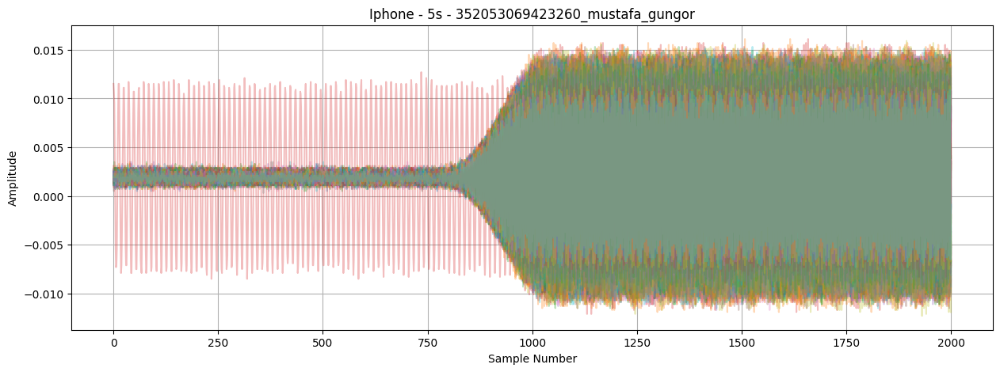

...

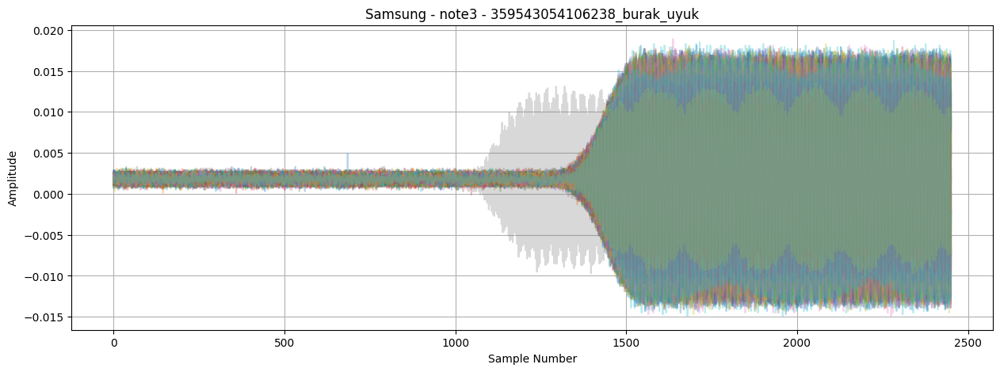

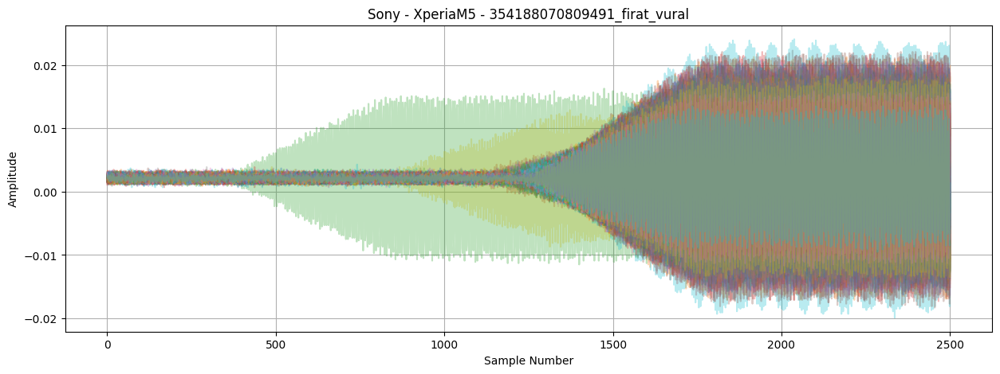

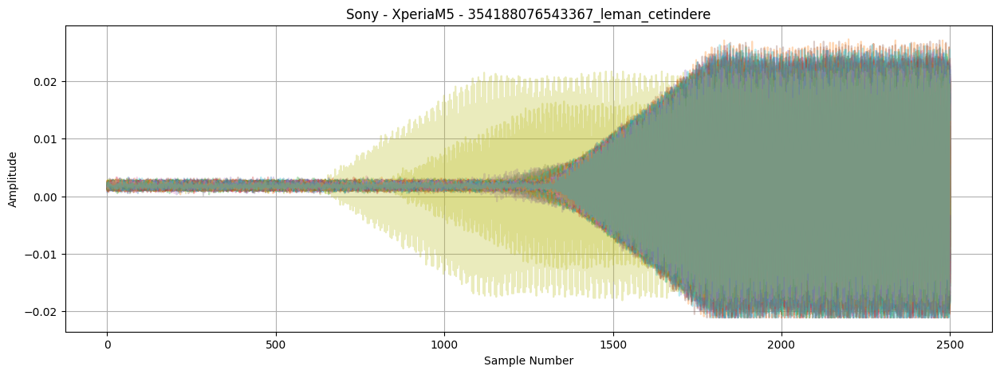

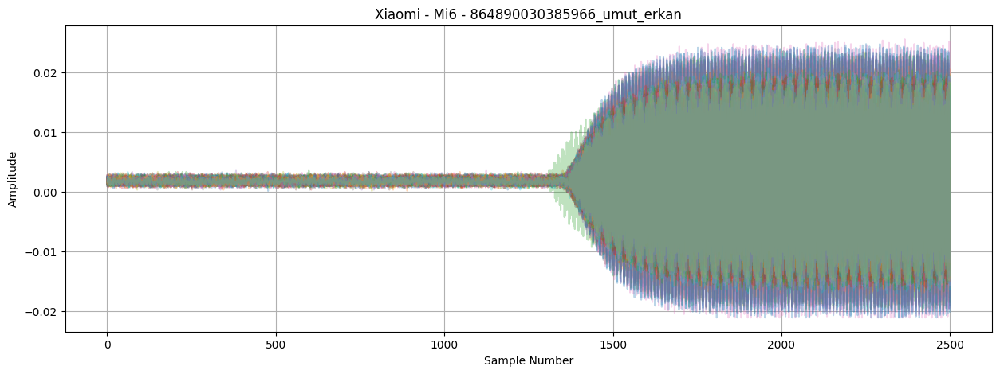

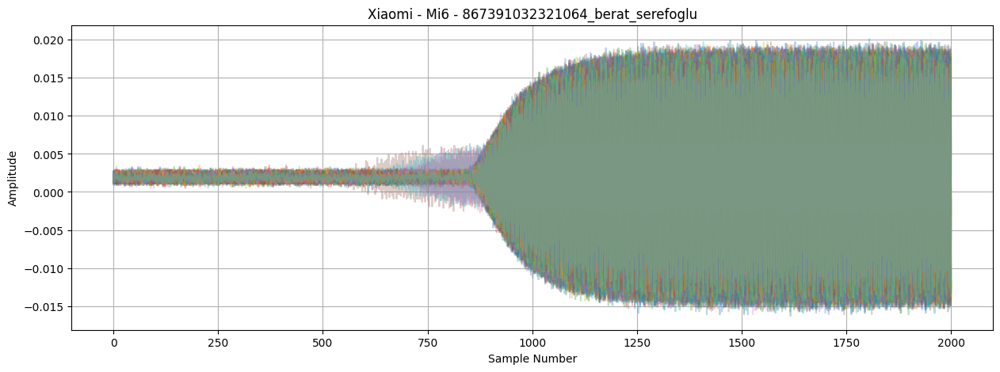

In [43]:
# ===============================================================
# 4.5 Plot All Users Automatically
# ===============================================================

import matplotlib.pyplot as plt
import numpy as np

# Get all unique Brand-Model-User combinations
groups = df[['Brand','Model','User']].drop_duplicates()

for _, row in groups.iterrows():

    brand = row['Brand']
    model = row['Model']
    user = row['User']

    plt.figure(figsize=(15,5))

    # Select signals of this user
    user_signals = [
        item["Signal"]
        for item in complete_dataset
        if item["Brand"] == brand
        and item["Model"] == model
        and item["User"] == user
    ]

    for signal in user_signals:
        plt.plot(signal, alpha=0.3)

    plt.title(f"{brand} - {model} - {user}")
    plt.xlabel("Sample Number")
    plt.ylabel("Amplitude")
    plt.grid(True)

    plt.show()

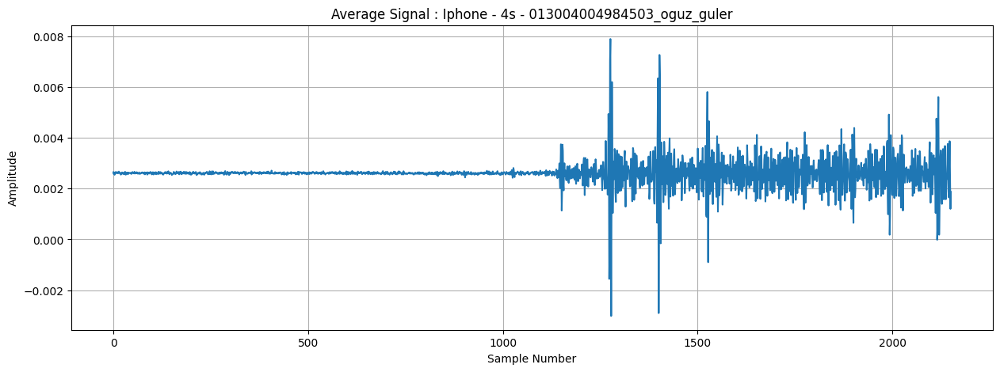

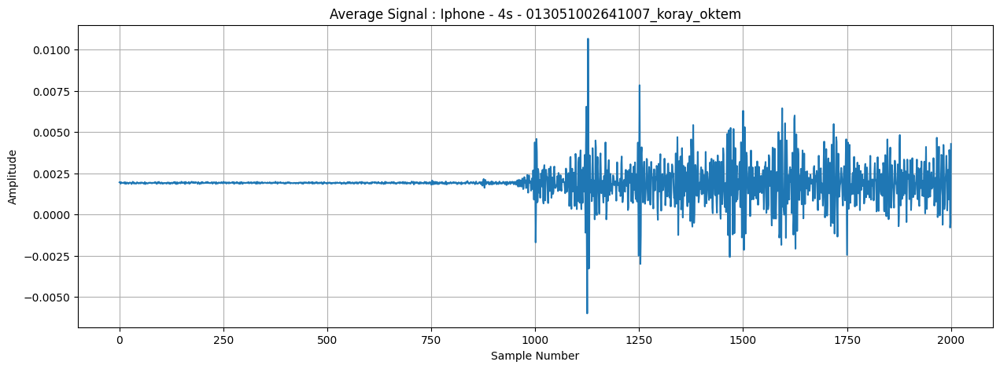

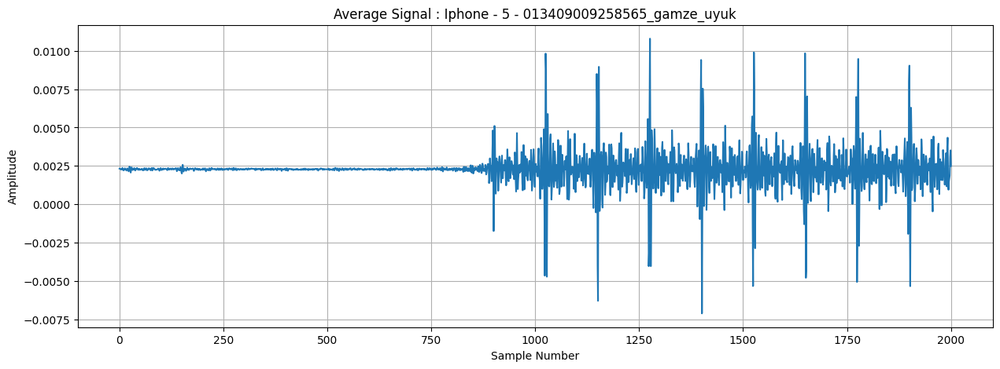

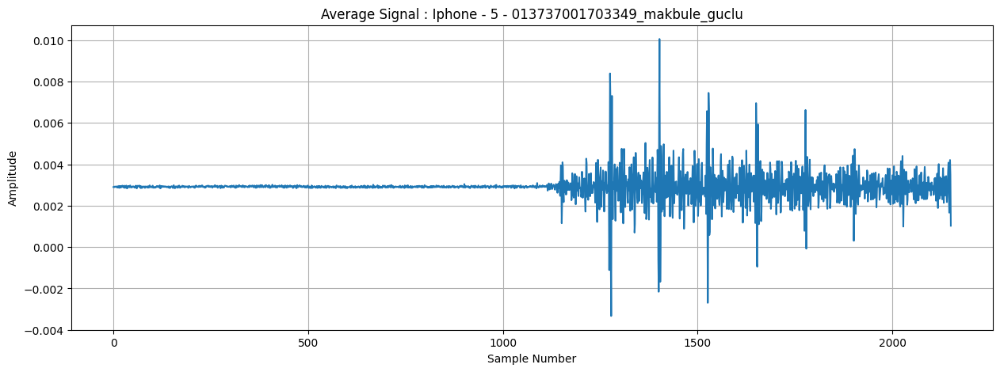

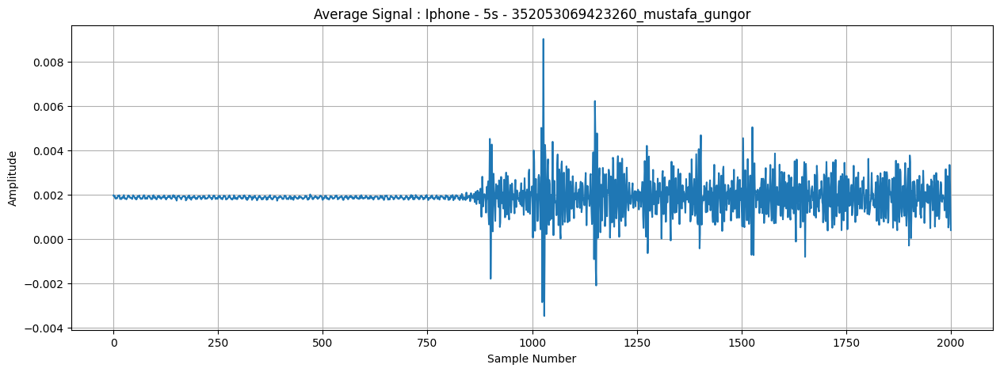

...

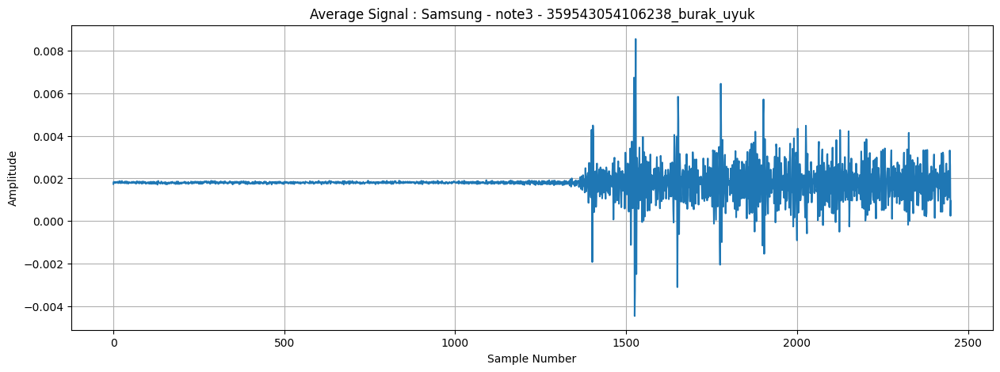

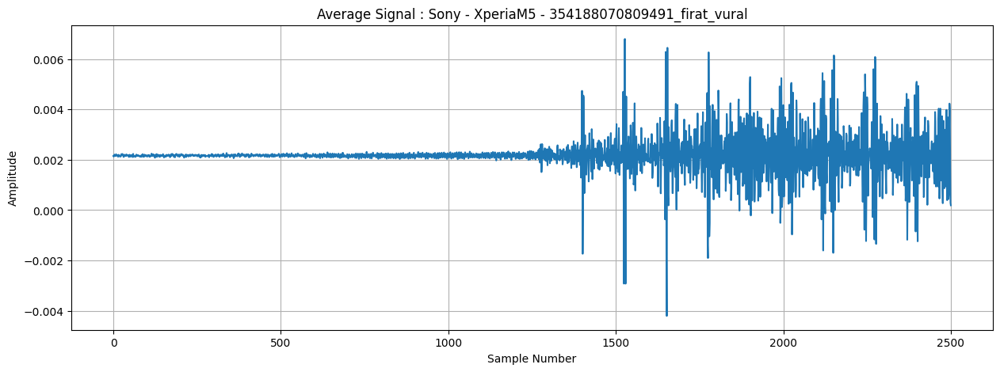

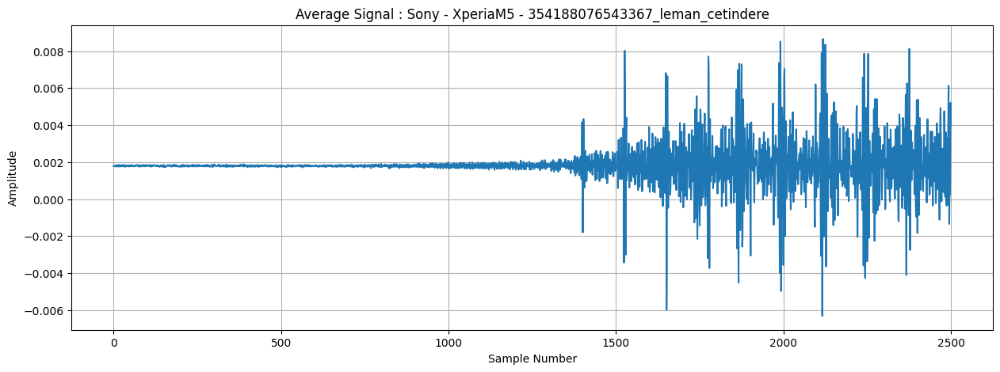

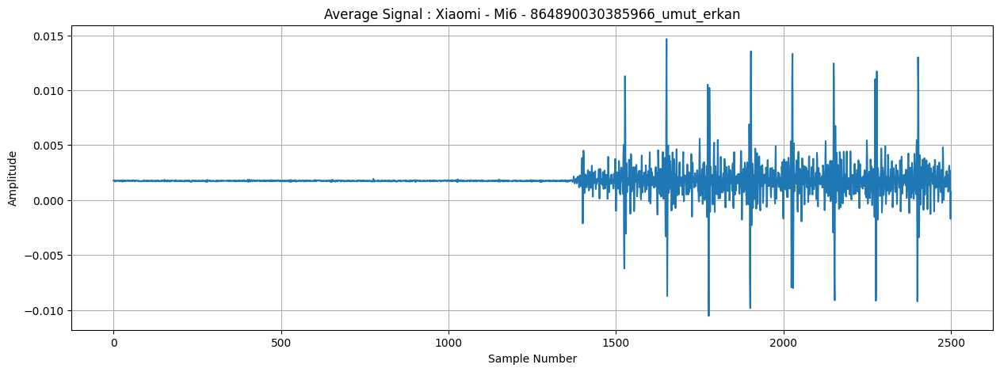

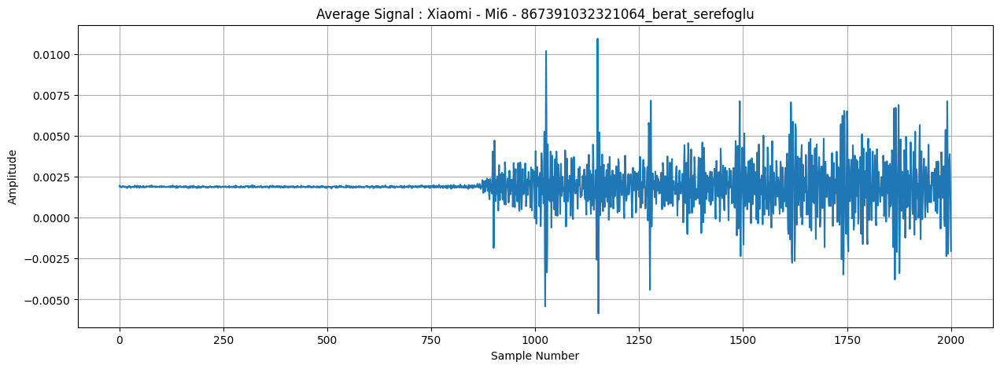

In [44]:
# ===============================================================
# 4.6 Average Signal of Every User
# ===============================================================

groups = df[['Brand','Model','User']].drop_duplicates()

for _, row in groups.iterrows():

    brand = row['Brand']
    model = row['Model']
    user = row['User']

    user_signals = [
        item["Signal"]
        for item in complete_dataset
        if item["Brand"] == brand
        and item["Model"] == model
        and item["User"] == user
    ]

    # Keep only equal-length signals
    min_length = min(len(s) for s in user_signals)
    user_signals = [s[:min_length] for s in user_signals]

    avg_signal = np.mean(user_signals, axis=0)

    plt.figure(figsize=(15,5))
    plt.plot(avg_signal)

    plt.title(f"Average Signal : {brand} - {model} - {user}")
    plt.xlabel("Sample Number")
    plt.ylabel("Amplitude")
    plt.grid(True)

    plt.show()

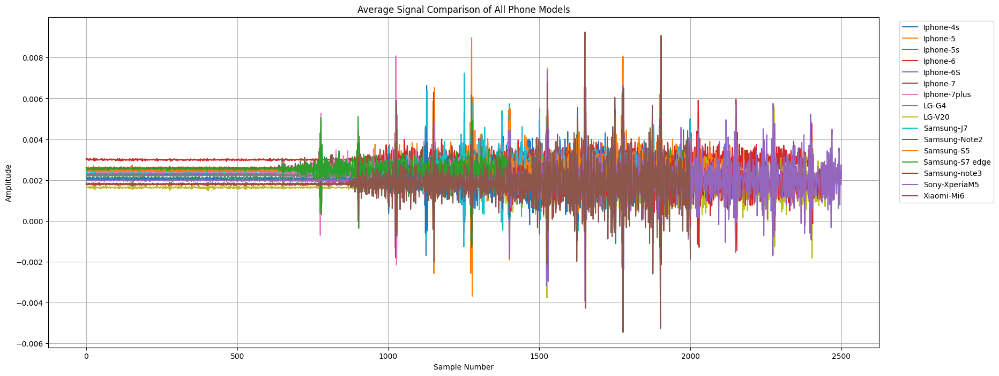

In [45]:
# ===============================================================
# 4.7 Compare Average Signal of ALL MODELS
# ===============================================================

plt.figure(figsize=(20,8))

models = df[['Brand','Model']].drop_duplicates()

for _, row in models.iterrows():

    brand = row['Brand']
    model = row['Model']

    signals = [
        item["Signal"]
        for item in complete_dataset
        if item["Brand"] == brand
        and item["Model"] == model
    ]

    min_length = min(len(s) for s in signals)
    signals = [s[:min_length] for s in signals]

    avg_signal = np.mean(signals, axis=0)

    plt.plot(avg_signal, label=f"{brand}-{model}")

plt.title("Average Signal Comparison of All Phone Models")
plt.xlabel("Sample Number")
plt.ylabel("Amplitude")
plt.legend(bbox_to_anchor=(1.02,1), loc="upper left")
plt.grid(True)

plt.show()

# 4.8 Compare Average Signal of ALL BRANDS

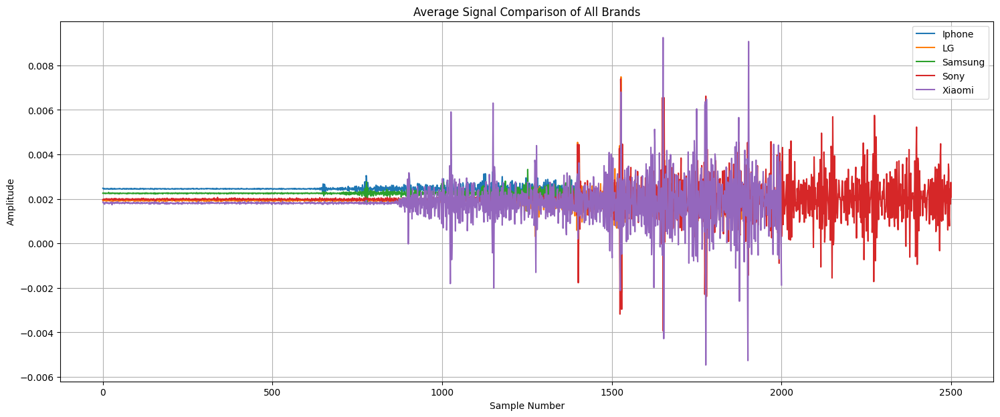

In [46]:
# ===============================================================
# 4.8 Compare Average Signal of ALL BRANDS
# ===============================================================

plt.figure(figsize=(18,7))

brands = df["Brand"].unique()

for brand in brands:

    signals = [
        item["Signal"]
        for item in complete_dataset
        if item["Brand"] == brand
    ]

    min_length = min(len(s) for s in signals)
    signals = [s[:min_length] for s in signals]

    avg_signal = np.mean(signals, axis=0)

    plt.plot(avg_signal, label=brand)

plt.title("Average Signal Comparison of All Brands")
plt.xlabel("Sample Number")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)

plt.show()

In [47]:
noise_mean = np.mean(signal[:200])

In [48]:
noise_std = np.std(signal[:200])

In [49]:
threshold = noise_mean + 5 * noise_std

In [50]:
transient_start = np.where(signal > threshold)[0][0]

In [51]:
noise = signal[:transient_start]

transient = signal[transient_start:transient_start+400]

steady = signal[transient_start+400:]

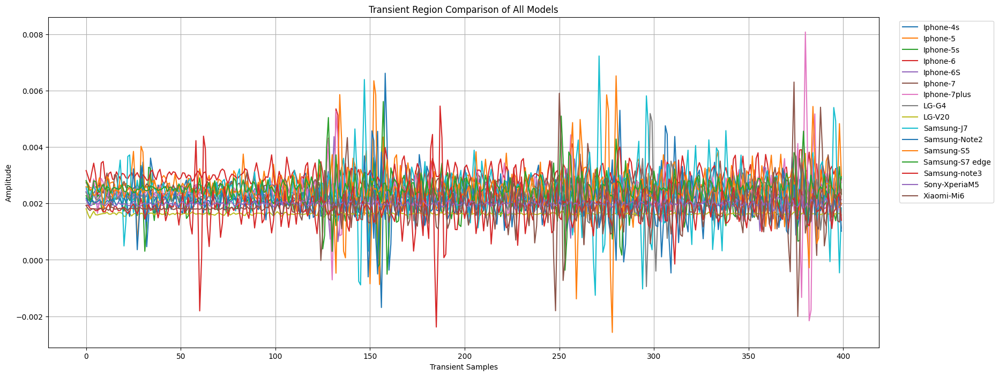

In [52]:
# ==========================================================
# SECTION 5.1 : Compare Transient Region of ALL Models
# ==========================================================

plt.figure(figsize=(20,8))

models = df[['Brand','Model']].drop_duplicates()

for _, row in models.iterrows():

    brand = row["Brand"]
    model = row["Model"]

    signals = [
        item["Signal"]
        for item in complete_dataset
        if item["Brand"] == brand and item["Model"] == model
    ]

    # Equal length
    min_len = min(len(s) for s in signals)
    signals = [s[:min_len] for s in signals]

    avg_signal = np.mean(signals, axis=0)

    # -------- Automatic Detection --------

    noise_mean = np.mean(avg_signal[:200])

    noise_std = np.std(avg_signal[:200])

    threshold = noise_mean + 5*noise_std

    transient_start = np.where(avg_signal > threshold)[0][0]

    transient = avg_signal[transient_start:transient_start+400]

    plt.plot(transient, label=f"{brand}-{model}")

plt.title("Transient Region Comparison of All Models")

plt.xlabel("Transient Samples")

plt.ylabel("Amplitude")

plt.legend(bbox_to_anchor=(1.02,1))

plt.grid(True)

plt.show()

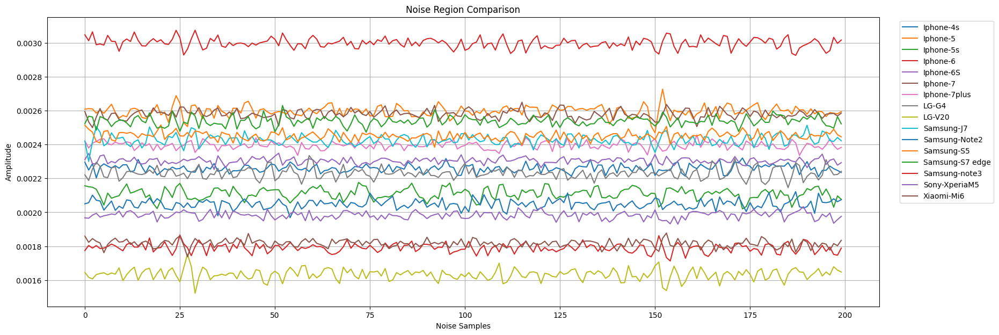

In [53]:
plt.figure(figsize=(20,7))

models = df[['Brand','Model']].drop_duplicates()

for _, row in models.iterrows():

    brand = row["Brand"]
    model = row["Model"]

    signals = [
        item["Signal"]
        for item in complete_dataset
        if item["Brand"] == brand and item["Model"] == model
    ]

    min_len = min(len(s) for s in signals)
    signals = [s[:min_len] for s in signals]

    avg_signal = np.mean(signals, axis=0)

    noise = avg_signal[:200]

    plt.plot(noise, label=f"{brand}-{model}")

plt.title("Noise Region Comparison")

plt.xlabel("Noise Samples")

plt.ylabel("Amplitude")

plt.legend(bbox_to_anchor=(1.02,1))

plt.grid(True)

plt.show()

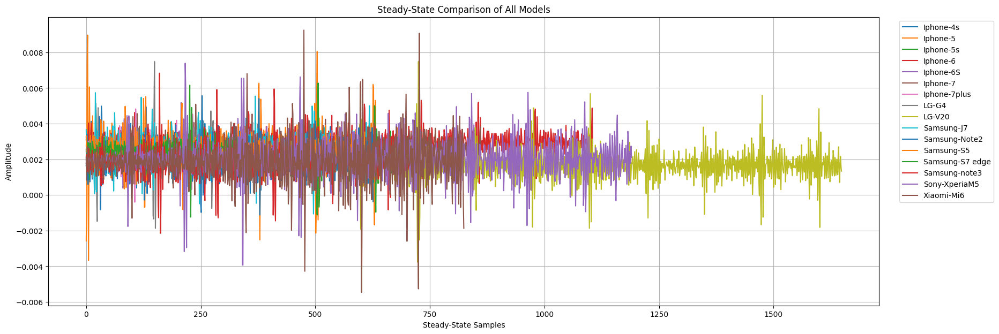

In [54]:
plt.figure(figsize=(20,7))

models = df[['Brand','Model']].drop_duplicates()

for _, row in models.iterrows():

    brand = row["Brand"]
    model = row["Model"]

    signals = [
        item["Signal"]
        for item in complete_dataset
        if item["Brand"] == brand and item["Model"] == model
    ]

    min_len = min(len(s) for s in signals)
    signals = [s[:min_len] for s in signals]

    avg_signal = np.mean(signals, axis=0)

    noise_mean = np.mean(avg_signal[:200])
    noise_std = np.std(avg_signal[:200])
    threshold = noise_mean + 5*noise_std

    transient_start = np.where(avg_signal > threshold)[0][0]

    steady = avg_signal[transient_start+400:]

    plt.plot(steady, label=f"{brand}-{model}")

plt.title("Steady-State Comparison of All Models")

plt.xlabel("Steady-State Samples")

plt.ylabel("Amplitude")

plt.legend(bbox_to_anchor=(1.02,1))

plt.grid(True)

plt.show()